# Poisson Distribution

The **Poisson distribution** counts the number of events occurring in a fixed interval of time or space, when events happen independently at a constant average rate $\lambda$. It has one unique property: **mean = variance = $\lambda$** — so overdispersion (variance > mean) in count data is a signal that Poisson doesn't fit.

| Property | Value |
|---|---|
| **Parameter** | $\lambda$ (rate, $\lambda > 0$) |
| **Support** | $\{0, 1, 2, 3, \ldots\}$ |
| **PMF** | $P(X=k) = \dfrac{e^{-\lambda}\,\lambda^k}{k!}$ |
| **Mean** | $\lambda$ |
| **Variance** | $\lambda$ |
| **Std Dev** | $\sqrt{\lambda}$ |
| **Skewness** | $1/\sqrt{\lambda}$ (right-skewed; decreases as $\lambda \uparrow$) |
| **Estimation** | $\hat{\lambda} = \bar{x}$ (MLE = sample mean) |
| **Normal approx** | Valid when $\lambda \geq 10$ |
| **Binomial limit** | $\text{Binomial}(n,p) \to \text{Poisson}(\lambda=np)$ as $n \to \infty$, $p \to 0$ |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Visualising the Poisson Distribution

### Panel 1 — PMF: Effect of Rate $\lambda$
Each line shows the **PMF** $P(X=k) = e^{-\lambda}\lambda^k/k!$ for different $\lambda$. At low $\lambda$ the distribution is strongly right-skewed with most mass near 0; as $\lambda$ increases the distribution becomes more symmetric and shifts right.

### Panel 2 — Equidispersion Check (Mean = Variance)
Side-by-side bar charts compare a Poisson sample (mean $\approx$ variance) with an overdispersed Negative Binomial sample (variance $\gg$ mean). This visual test is the first step in deciding whether Poisson is appropriate for count data.

### Panel 3 — Normal Approximation at Large $\lambda$
For $\lambda=15 \geq 10$, the Poisson PMF (bars) is well-approximated by a $N(\lambda, \sqrt{\lambda})$ density (red curve), confirming the Poisson-Normal convergence for large rates.


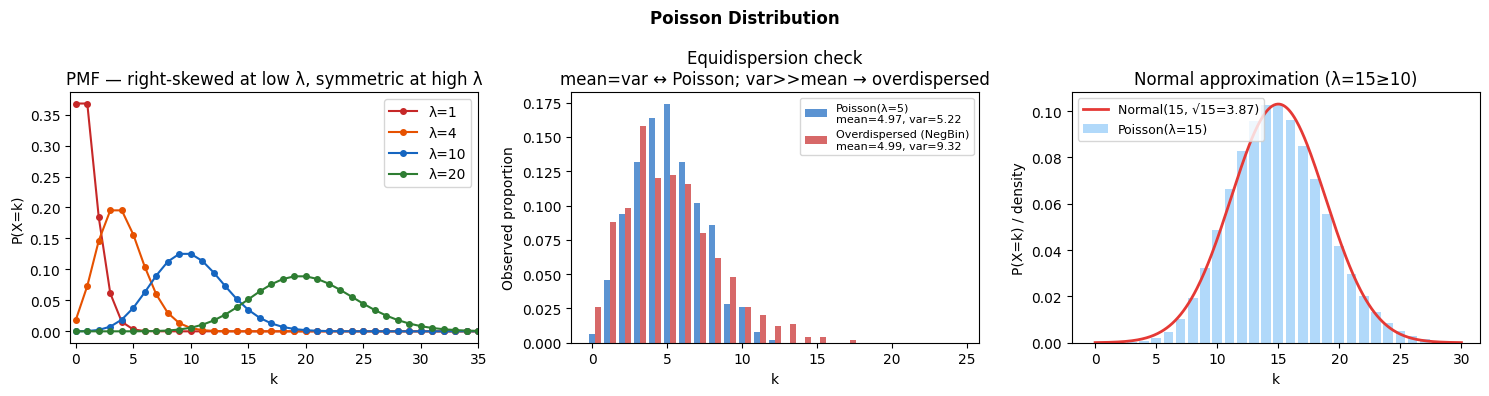

Poisson test: observed=7, expected rate=5.0
P(X ≥ 7 | λ=5.0) = 0.2378


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Poisson Distribution', fontsize=12, fontweight='bold')

# PMF — varying λ
for lam, color, label in [(1,  '#C62828', 'λ=1'),
                            (4,  '#E65100', 'λ=4'),
                            (10, '#1565C0', 'λ=10'),
                            (20, '#2E7D32', 'λ=20')]:
    k = np.arange(0, 40)
    pmf = stats.poisson(lam).pmf(k)
    axes[0].plot(k, pmf, 'o-', color=color, linewidth=1.5, markersize=4, label=f'λ={lam}')
axes[0].set_title('PMF — right-skewed at low λ, symmetric at high λ')
axes[0].set_xlabel('k'); axes[0].set_ylabel('P(X=k)')
axes[0].set_xlim(-0.5, 35)
axes[0].legend()

# Mean = Variance check (overdispersion test)
np.random.seed(42)
# Poisson data: mean ≈ variance
lam_true = 5
poisson_data = stats.poisson(lam_true).rvs(500)
# Overdispersed: Negative Binomial
nb_data = stats.nbinom(n=5, p=0.5).rvs(500)

datasets = [('Poisson(λ=5)', poisson_data, '#1565C0'),
            ('Overdispersed (NegBin)', nb_data, '#C62828')]
x_vals = np.arange(0, 25)
for label, data, color in datasets:
    pmf_obs = np.array([(data == k).mean() for k in x_vals])
    axes[1].bar(x_vals + (0 if color == '#1565C0' else 0.4), pmf_obs,
                width=0.4, color=color, alpha=0.7, label=f'{label}\nmean={data.mean():.2f}, var={data.var():.2f}')
axes[1].set_title('Equidispersion check\nmean=var ↔ Poisson; var>>mean → overdispersed')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Observed proportion')
axes[1].legend(fontsize=8)

# Normal approximation at large λ
lam = 15
k_all = np.arange(0, 30)
pmf_exact = stats.poisson(lam).pmf(k_all)
x_cont = np.linspace(0, 30, 400)
normal_approx = stats.norm(lam, np.sqrt(lam)).pdf(x_cont)

axes[2].bar(k_all, pmf_exact, color='#90CAF9', alpha=0.7, label=f'Poisson(λ={lam})')
axes[2].plot(x_cont, normal_approx, color='#E53935', linewidth=2,
             label=f'Normal({lam}, √{lam}={np.sqrt(lam):.2f})')
axes[2].set_title(f'Normal approximation (λ={lam}≥10)')
axes[2].set_xlabel('k'); axes[2].set_ylabel('P(X=k) / density')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Poisson test
observed_count = 7
expected_rate  = 5.0
p_val = 1 - stats.poisson(expected_rate).cdf(observed_count - 1)
print(f"Poisson test: observed={observed_count}, expected rate={expected_rate}")
print(f"P(X ≥ {observed_count} | λ={expected_rate}) = {p_val:.4f}")

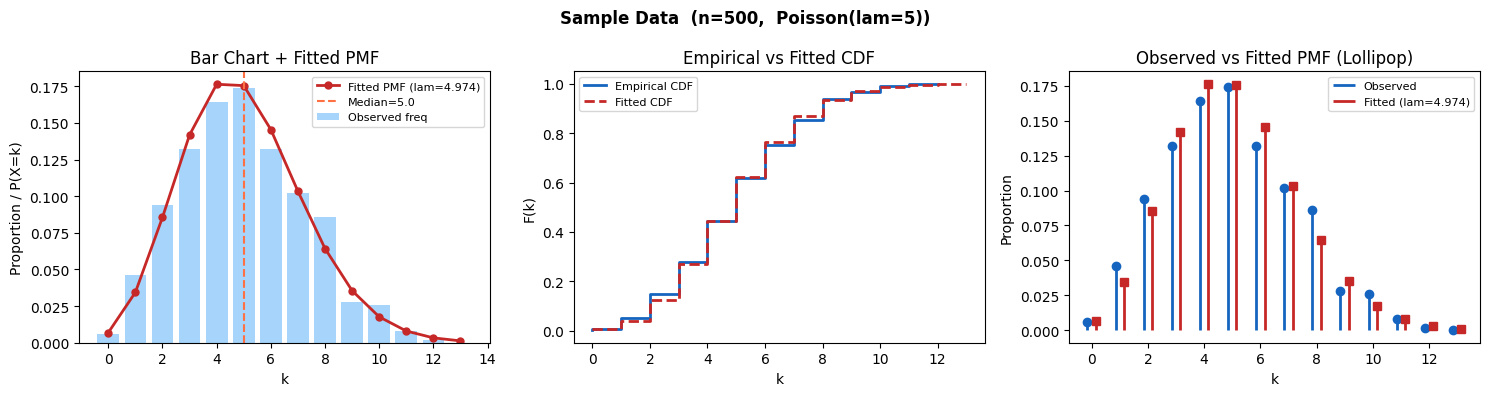

n=500  mean=4.9740  median=5.0000  std=2.2873  lambda_hat=4.9740


In [3]:
# Sample data plots — Poisson(lam=5)
np.random.seed(42)
sample_d = stats.poisson.rvs(mu=5, size=500)
lam_hat = sample_d.mean()
k_vals = np.arange(0, sample_d.max() + 2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sample Data  (n=500,  Poisson(lam=5))', fontsize=12, fontweight='bold')

# Bar chart + fitted PMF
obs_counts = np.bincount(sample_d, minlength=len(k_vals))
axes[0].bar(k_vals, obs_counts / len(sample_d), color='#90CAF9', alpha=0.8, label='Observed freq')
axes[0].plot(k_vals, stats.poisson.pmf(k_vals, lam_hat), 'o-', color='#C62828',
             linewidth=2, markersize=5, label=f'Fitted PMF (lam={lam_hat:.3f})')
axes[0].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.1f}')
axes[0].set_title('Bar Chart + Fitted PMF')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Proportion / P(X=k)')
axes[0].legend(fontsize=8)

# Empirical vs fitted CDF
sorted_s = np.sort(sample_d)
ecdf_y = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
axes[1].step(sorted_s, ecdf_y, color='#1565C0', linewidth=2, label='Empirical CDF')
axes[1].step(k_vals, stats.poisson.cdf(k_vals, lam_hat), color='#C62828',
             linewidth=2, linestyle='--', where='post', label='Fitted CDF')
axes[1].set_title('Empirical vs Fitted CDF')
axes[1].set_xlabel('k'); axes[1].set_ylabel('F(k)')
axes[1].legend(fontsize=8)

# Lollipop: observed vs fitted PMF
k_range = np.arange(0, sample_d.max() + 2)
obs_pmf = np.array([(sample_d == k).mean() for k in k_range])
fitted_pmf = stats.poisson.pmf(k_range, lam_hat)
axes[2].vlines(k_range - 0.15, 0, obs_pmf, color='#1565C0', linewidth=2, label='Observed')
axes[2].plot(k_range - 0.15, obs_pmf, 'o', color='#1565C0', markersize=6)
axes[2].vlines(k_range + 0.15, 0, fitted_pmf, color='#C62828', linewidth=2,
               label=f'Fitted (lam={lam_hat:.3f})')
axes[2].plot(k_range + 0.15, fitted_pmf, 's', color='#C62828', markersize=6)
axes[2].set_title('Observed vs Fitted PMF (Lollipop)')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Proportion')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"n={len(sample_d)}  mean={sample_d.mean():.4f}  median={np.median(sample_d):.4f}  std={sample_d.std(ddof=1):.4f}  lambda_hat={lam_hat:.4f}")


## Key Takeaways

| | |
|---|---|
| **Mean = Variance** | The defining equidispersion property — test this on your data first |
| **Overdispersion** | $\text{var} \gg \text{mean}$ → use Negative Binomial instead |
| **Underdispersion** | $\text{var} \ll \text{mean}$ → consider Conway-Maxwell-Poisson |
| **Estimation** | $\hat{\lambda} = \bar{x}$ (sample mean is the MLE) |
| **Normal approx** | Use when $\lambda \geq 10$ |
| **Additive** | Sum of $k$ independent $\text{Poisson}(\lambda_i) \sim \text{Poisson}(\sum \lambda_i)$ |
| **Use cases** | Call centre arrivals, website clicks per minute, defects per unit area, rare disease counts |
| **Exponential link** | Inter-arrival times of $\text{Poisson}(\lambda)$ process $\sim \text{Exponential}(1/\lambda)$ |
